# New IC → Residual Pipeline (WN-based, ZA Baseline)

Uses white-noise-derived psi1 (z=0) instead of Quijote ICs (z=127 2LPT snapshots).
`growth_factor_D = 1` because delta is already at z=0 scale.

In [1]:
print('Loading libraries and setting up environment...')

import sys, os
from pathlib import Path

nb_dir = Path.cwd()
if not (nb_dir / 'new_config_ZA.py').exists() and (nb_dir / 'src' / 'new_config_ZA.py').exists():
    nb_dir = nb_dir / 'src'
repo_root = nb_dir.parent

for p in (str(nb_dir), str(repo_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

import importlib
import new_config_ZA as cfg
import new_dddf

importlib.reload(cfg)
importlib.reload(new_dddf)

from new_dddf import NewDDDF

# ── Derived constants ──────────────────────────────────────────────
N_p        = cfg.N_p
L          = cfg.L
boxsize    = cfg.boxsize
MAS        = cfg.MAS
threads    = cfg.threads
grid_size  = N_p
data_dir   = cfg.data_dir
model_dir  = cfg.model_dir

print('Initializing NewDDDF (growth_factor_D=1) and Veck...')
dl        = NewDDDF(cfg.Omega_m, threads)
veck_main = dl.Veck(dl, N_p, boxsize, padding=0)

print(f'hostname: {os.popen("hostname").read().strip()}')
print(f'N_p={N_p}, boxsize={boxsize}, data_dir={data_dir}, model_dir={model_dir}')
print(f'growth_factor_D = {dl.growth_factor_D}')

Loading libraries and setting up environment...
Initializing NewDDDF (growth_factor_D=1) and Veck...
hostname: nid001124
N_p=256, boxsize=1000.0, data_dir=new_tophat0.4_ZA, model_dir=new_tophat0.4_ZA_v3
growth_factor_D = 1.0


## 1. Training: IC → Residual

In [2]:
import numpy as np
from model.new_gen_patches import extract_patches
import model.new_train_model as train_module
from new_pipeline_ZA import compute_za_baseline, free_gpu_memory

importlib.reload(cfg)

patch_size = cfg.patch_size
padding    = cfg.padding
overlap    = cfg.overlap
rotate     = cfg.vec_rotate  # False for vector fields

# ── Section settings ──────────────────────────────────────────────
train_realizations = cfg.train_realizations   # e.g. list(range(16))
coef_file = None  # fit from scratch for WN-based pipeline
# ──────────────────────────────────────────────────────────────────

train_path = cfg.vec_training_data_path(
    train_realizations, patch_size, padding, overlap, rotate, N_p)

if os.path.exists(train_path):
    cached = np.load(train_path)
    input_patches  = cached['input_patches']
    target_patches = cached['target_patches']
    print(f'Combined training data already exists, loaded: {train_path}')
    print(f'{input_patches.shape[0]} patch pairs, shape {input_patches.shape[1:]}')
else:
    all_input_patches  = []
    all_target_patches = []

    for r in train_realizations:
        train_path_r = cfg.vec_training_data_path(
            r, patch_size, padding, overlap, rotate, N_p)
        if os.path.exists(train_path_r):
            cached = np.load(train_path_r)
            inp_r = cached['input_patches']
            tgt_r = cached['target_patches']
            print(f'  [r{r}] training file exists, loaded: {train_path_r}')
        else:
            # Load WN data
            wn_info_r = dl.get_snapshot_wn(
                cfg.wn_psi1_path(r, N_p),
                cfg.wn_qinit_path(r, N_p),
                boxsize, grid_size)
            q_init_r    = wn_info_r['q_init']
            init_delta_r = wn_info_r['delta']

            # Load final N-body snapshot
            final_info_r = dl.get_snapshot(
                cfg.final_snapshot_path(r, N_p),
                cfg.snapshot_format(N_p),
                boxsize, grid_size)

            # Compute target psi_div AND full displacement field
            tgt_psi_div_r, tgt_psi_r = dl.compute_target_psi_wn(
                q_init_r, final_info_r['pos'], N_p, boxsize, veck_main)

            # Compute ZA baseline (returns 4-tuple with vector psi)
            bf_psi_div_r, bf_psi_r, _, _ = compute_za_baseline(
                dl, init_delta_r, tgt_psi_div_r,
                q_init_r, final_info_r['delta'],
                veck_main, N_p, boxsize, MAS,
                r, data_dir, L,
                coef_file=coef_file,
                overwrite=False,
            )

            # Residual is in vector displacement space
            residual_psi_r = tgt_psi_r - bf_psi_r
            print(f'  [r{r}] residual psi chi^2 = {np.mean(residual_psi_r**2):.6e}')

            # Extract 4D patches: input=best_fit_psi (N,N,N,3), target=residual_psi (N,N,N,3)
            inp_r = extract_patches(bf_psi_r,       patch_size, padding, overlap, rotate)
            tgt_r = extract_patches(residual_psi_r, patch_size, padding, overlap, rotate)

            os.makedirs(os.path.dirname(train_path_r), exist_ok=True)
            np.savez(
                train_path_r,
                input_patches=inp_r,
                target_patches=tgt_r,
                patch_size=patch_size,
                padding=padding,
                overlap=overlap,
                realization=r,
            )
            print(f'  [r{r}] saved: {train_path_r}')
            del wn_info_r, final_info_r, tgt_psi_div_r, tgt_psi_r, bf_psi_div_r, bf_psi_r, residual_psi_r

        all_input_patches.append(inp_r)
        all_target_patches.append(tgt_r)

    input_patches  = np.concatenate(all_input_patches,  axis=0)
    target_patches = np.concatenate(all_target_patches, axis=0)
    assert input_patches.shape == target_patches.shape
    print(f'{input_patches.shape[0]} patch pairs from '
          f'{len(train_realizations)} realization(s), shape {input_patches.shape[1:]}')

    np.savez(train_path,
             input_patches=input_patches, target_patches=target_patches,
             patch_size=patch_size, padding=padding, overlap=overlap)
    print(f'combined training data saved: {train_path}')

/global/u1/l/liuyh15/WorkSpace/DDDF/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Combined training data already exists, loaded: /pscratch/sd/l/liuyh15/DDDF/data/za_psi_vec/training-data-VEC-N256PS20P2O00RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15.npz
35152 patch pairs, shape (24, 24, 24, 3)


In [3]:
free_gpu_memory()

importlib.reload(cfg)

# ── Section settings ──────────────────────────────────────────────
overwrite_train = False   # True -> force retrain
# ──────────────────────────────────────────────────────────────────

model_name = cfg.vec_gan_model_name(
    train_realizations, patch_size, padding, rotate, N_p)

train_module.train_gan(
    training_data_path=train_path,
    save_file_name=model_name,
    batch_size=cfg.vec_batch_size,
    epochs=cfg.epochs,          # 5 in new_config
    lr_g=cfg.gan_lr_g,
    lr_d=cfg.gan_lr_d,
    lambda_pixel=cfg.gan_lambda_pixel,
    n_disc_layers=cfg.gan_n_disc_layers,
    lambda_fm=cfg.gan_lambda_fm,
    lambda_gp=cfg.gan_lambda_gp,
    d_update_interval=cfg.gan_d_update_interval,
    use_spectral_norm=cfg.gan_use_spectral_norm,
    use_multiscale_disc=cfg.gan_use_multiscale_disc,
    disc_base_channels=cfg.gan_disc_base_channels,
    checkpoint_interval=cfg.checkpoint_interval,
    resume_checkpoint='auto',
    overwrite=overwrite_train,
)

GPU memory in use: 0.00 GB


/global/u1/l/liuyh15/WorkSpace/DDDF/.venv/lib/python3.11/site-packages/torch/__init__.py:1146: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


Detected 3 channel(s), spatial shape (24, 24, 24)
Auto-selected number of pooling levels: 4 (min side=24)
Generator base_channels: 32
Using device: cuda
Generator parameters: 10,044,867
Discriminator parameters: 1,135,810
n_channels=3, lambda_pixel=5.0, lambda_fm=20.0, n_disc_layers=3, d_update_interval=1, use_spectral_norm=False, sn_impl=native, batch_size=512, use_multiscale_disc=True, disc_base_channels=64
Resuming training from checkpoint: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e348.ckpt
Completed 348 epochs, continue training to epoch 500.
Starting epoch 349/500...


Epoch 349/500: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [01:00<00:00,  1.15batch/s, D=-0.1137, G=4.0911, eta=01:46:24, fm=0.0188, gp=0.0003, px=0.2460]


Epoch 349/500,  loss_G=4.078797,  loss_D=-0.115813,  lr_G=8.49e-05,  lr_D=8.49e-05,  epoch_time=60.2s,  avg_epoch_time=60.2s,  train_eta=2026-04-23 04:17:56
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e349.ckpt
Starting epoch 350/500...


...

Epoch 498/500,  loss_G=4.832878,  loss_D=-0.112433,  lr_G=5.21e-05,  lr_D=5.21e-05,  epoch_time=57.1s,  avg_epoch_time=57.3s,  train_eta=2026-04-23 04:11:03
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e498.ckpt
Starting epoch 499/500...


Epoch 499/500: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [00:56<00:00,  1.21batch/s, D=-0.1245, G=4.8429, eta=04:10:06, fm=0.0164, gp=0.0001, px=0.2208]


Epoch 499/500,  loss_G=4.842506,  loss_D=-0.112320,  lr_G=5.13e-05,  lr_D=5.13e-05,  epoch_time=57.0s,  avg_epoch_time=57.3s,  train_eta=2026-04-23 04:11:03
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e499.ckpt
Starting epoch 500/500...


Epoch 500/500: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [00:56<00:00,  1.21batch/s, D=-0.1171, G=4.8468, eta=04:11:03, fm=0.0163, gp=0.0004, px=0.2208]


Epoch 500/500,  loss_G=4.846722,  loss_D=-0.112344,  lr_G=5.05e-05,  lr_D=5.05e-05,  epoch_time=57.0s,  avg_epoch_time=57.3s,  train_eta=2026-04-23 04:11:03
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.ckpt
Total training time: 8739.9s
GAN training complete, generator saved to: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.pth


## 2. Verification

Loading psi1 from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/psi1_grid_z127_seed000_n256.npz
Loading q_init from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/q_init_seed000_n256.npz
psi1 grid: 256^3,  dplus=101.025389,  box_file=1000000.0 (kpc/h)
delta(z=0): mean=1.164153e-10, std=1.918638
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading ZA baseline psi_div from /pscratch/sd/l/liuyh15/DDDF/data/new_tophat0.4_ZA/za-baselineL1N256-0.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.pth (pools=4, device=cuda)


apply_model (patch-batch): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 986.93it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=2.5s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


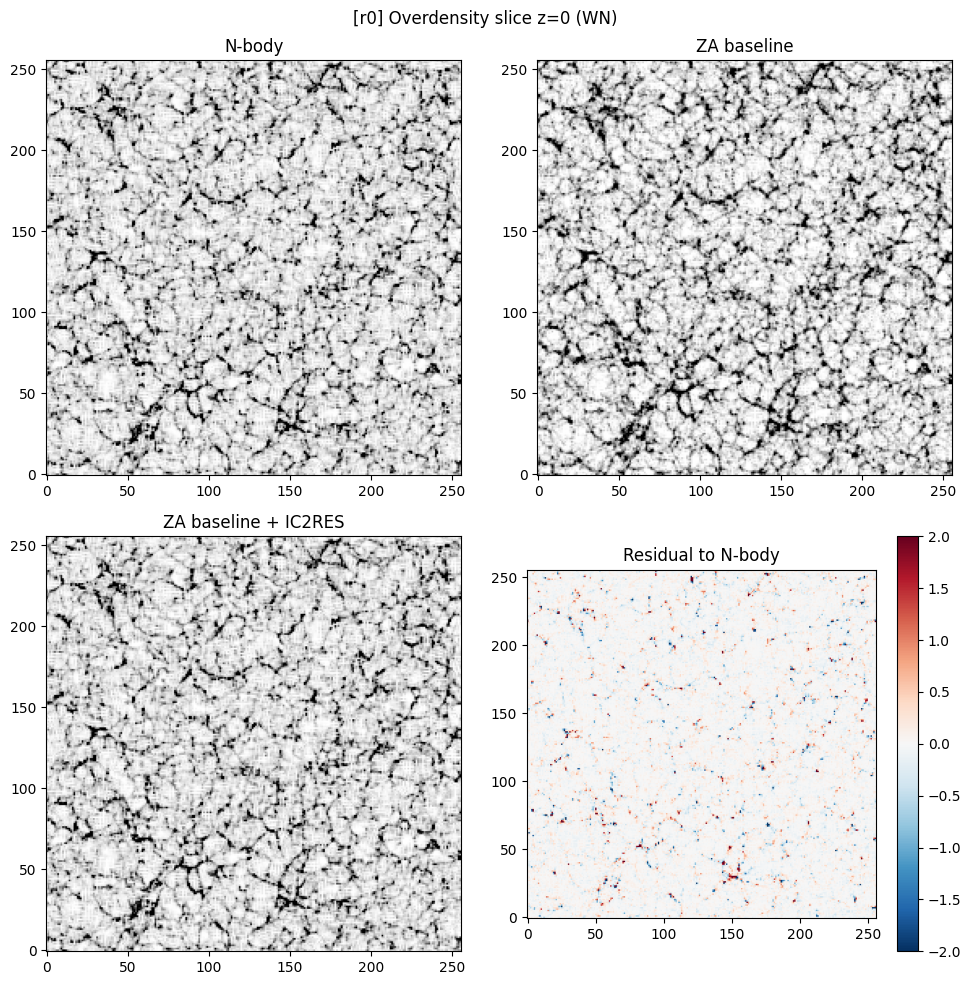

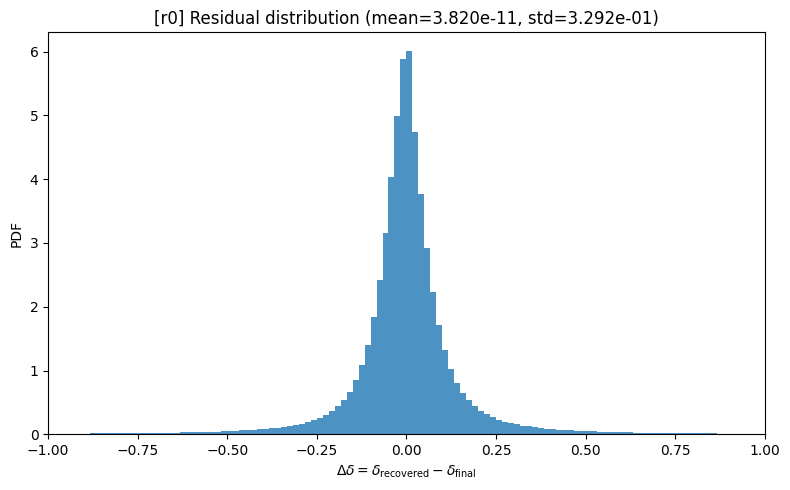

[r0] Nyquist target k = 0.804248, nearest-bin k = 0.807336


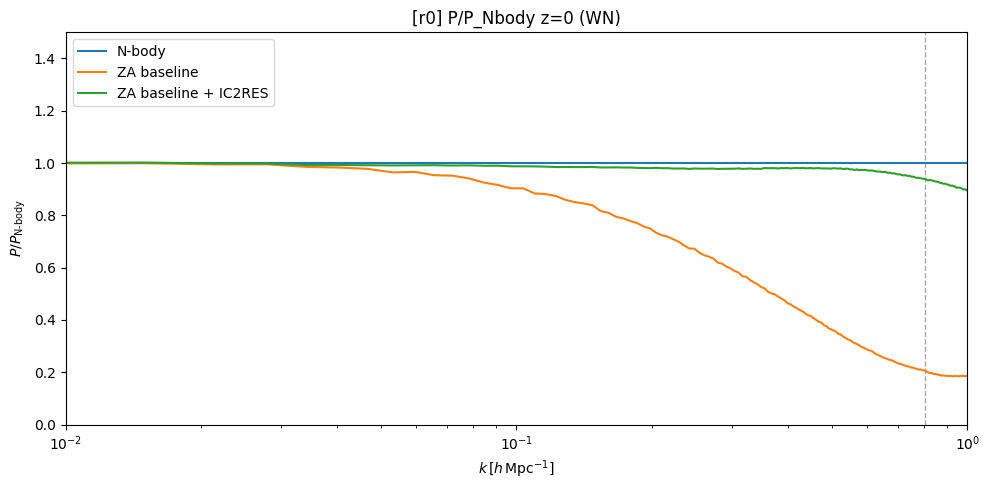

[r0] N-body P/P_N-body @Nyquist = 100.00%
[r0] ZA baseline P/P_N-body @Nyquist = 20.53%
[r0] ZA baseline + IC2RES P/P_N-body @Nyquist = 93.88%

Computing bispectrum of the field...
Time to compute bispectrum = 5.70

Computing bispectrum of the field...
Time to compute bispectrum = 5.78

Computing bispectrum of the field...
Time to compute bispectrum = 5.78


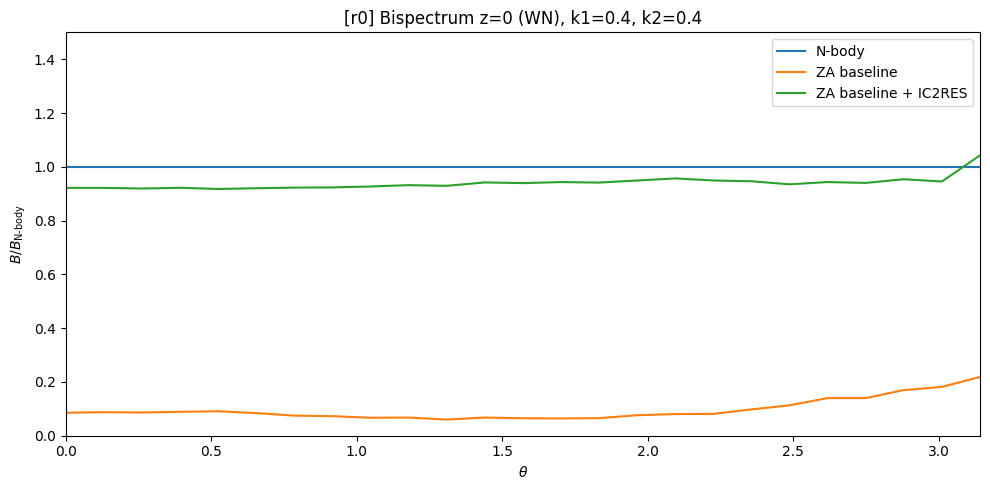

[r0] ZA baseline chi^2 (k<=0.3) = 5.085591e-02
[r0] ZA baseline + IC2RES chi^2 (k<=0.3) = 2.584478e-04
Loading psi1 from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/psi1_grid_z127_seed019_n256.npz
Loading q_init from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/q_init_seed019_n256.npz
psi1 grid: 256^3,  dplus=101.025389,  box_file=1000000.0 (kpc/h)
delta(z=0): mean=0.000000e+00, std=1.918345
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading ZA baseline psi_div from /pscratch/sd/l/liuyh15/DDDF/data/new_tophat0.4_ZA/za-baselineL1N256-19.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.pth (pools=4, device=cuda)


apply_model (patch-batch): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2197/2197 [00:02<00:00, 1025.17it/s]


apply_model done: step=20, overlap=0.0, batch_size=32, elapsed=2.4s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


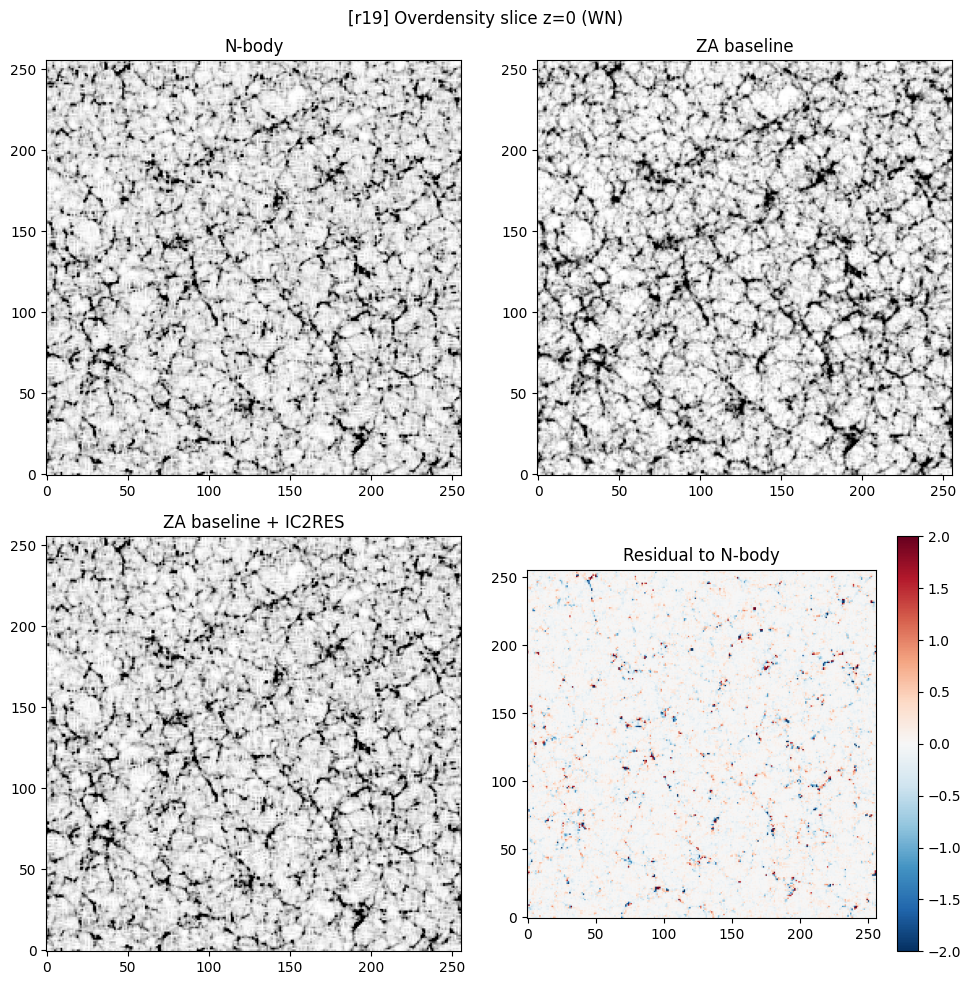

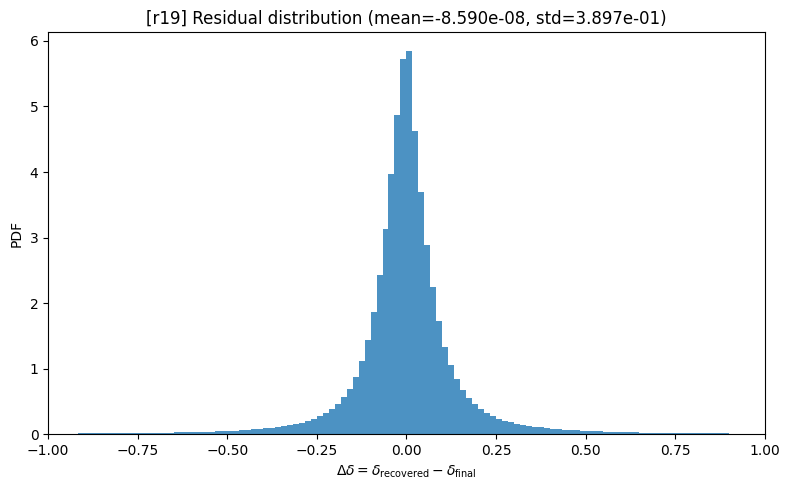

[r19] Nyquist target k = 0.804248, nearest-bin k = 0.807336


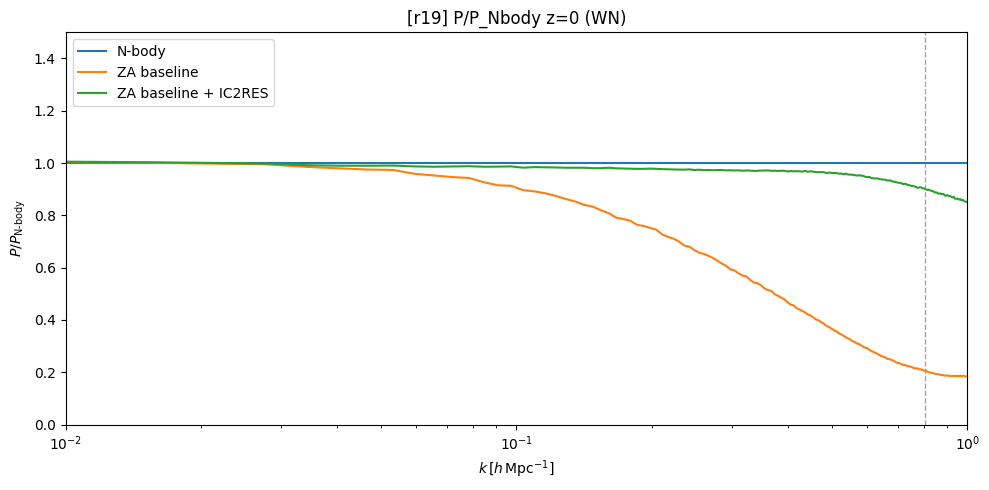

[r19] N-body P/P_N-body @Nyquist = 100.00%
[r19] ZA baseline P/P_N-body @Nyquist = 20.73%
[r19] ZA baseline + IC2RES P/P_N-body @Nyquist = 89.99%

Computing bispectrum of the field...
Time to compute bispectrum = 5.73

Computing bispectrum of the field...
Time to compute bispectrum = 5.74

Computing bispectrum of the field...
Time to compute bispectrum = 5.75


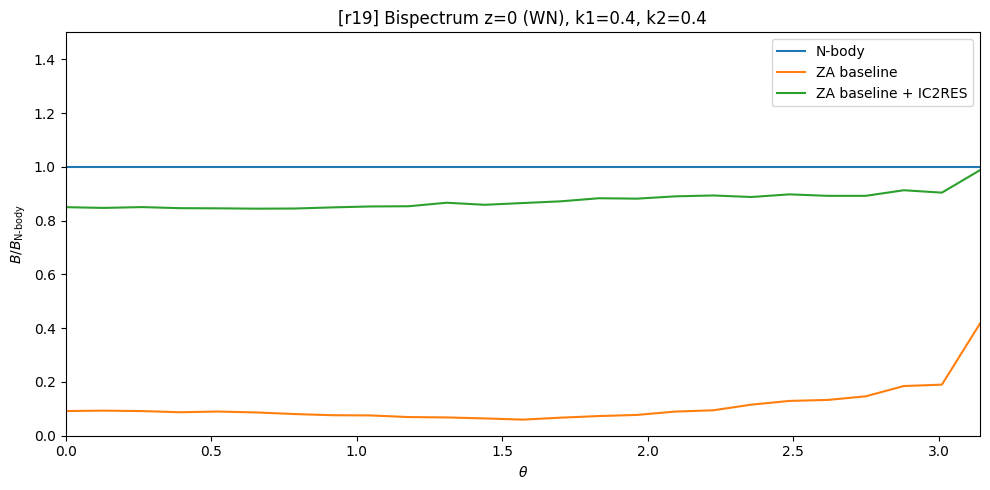

[r19] ZA baseline chi^2 (k<=0.3) = 5.047996e-02
[r19] ZA baseline + IC2RES chi^2 (k<=0.3) = 3.847047e-04


{'realization': 19,
 'checkpoint': '/pscratch/sd/l/liuyh15/DDDF/models/za_psi_vec_v3/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e500.pth',
 'chi2': {'ZA baseline': 0.0504799570250019,
  'ZA baseline + IC2RES': 0.0003847047341260398},
 'labels': ['N-body', 'ZA baseline', 'ZA baseline + IC2RES']}

In [4]:
importlib.reload(cfg)
import new_verify_ZA as new_verify
importlib.reload(new_verify)
from new_verify_ZA import verify_realization

k_cut = cfg.k_cut
verify_realization(realization=0, k_cut=k_cut)
verify_realization(realization=19, k_cut=k_cut)